In [16]:
# warmup code tests
import math

def lr_lambda(current_step, warmup_steps, total_steps):
    if current_step < warmup_steps:
        # Linear warmup
        print('linear warmup')
        return float(current_step) / float(max(1, warmup_steps))
    # Cosine decay
    print('cosine decay')
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    print('progresss = ', progress)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

In [17]:
lr_lambda(current_step=0, warmup_steps=5, total_steps=10)

linear warmup


0.0

In [18]:
lr_lambda(current_step=1, warmup_steps=5, total_steps=10)

linear warmup


0.2

In [19]:
lr_lambda(current_step=2, warmup_steps=5, total_steps=10)

linear warmup


0.4

In [20]:
lr_lambda(current_step=3, warmup_steps=5, total_steps=10)

linear warmup


0.6

In [21]:
lr_lambda(current_step=4, warmup_steps=5, total_steps=10)

linear warmup


0.8

In [22]:
lr_lambda(current_step=5, warmup_steps=5, total_steps=10)

cosine decay
progresss =  0.0


1.0

In [23]:
lr_lambda(current_step=6, warmup_steps=5, total_steps=10)

cosine decay
progresss =  0.2


0.9045084971874737

In [24]:
lr_lambda(current_step=7, warmup_steps=5, total_steps=10)

cosine decay
progresss =  0.4


0.6545084971874737

In [25]:
lr_lambda(current_step=10, warmup_steps=5, total_steps=10)

cosine decay
progresss =  1.0


0.0

/var/folders/80/l8hhvwv56v336dy_j3ctk1vh0000gn/T/ipykernel_78740/1530513158.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


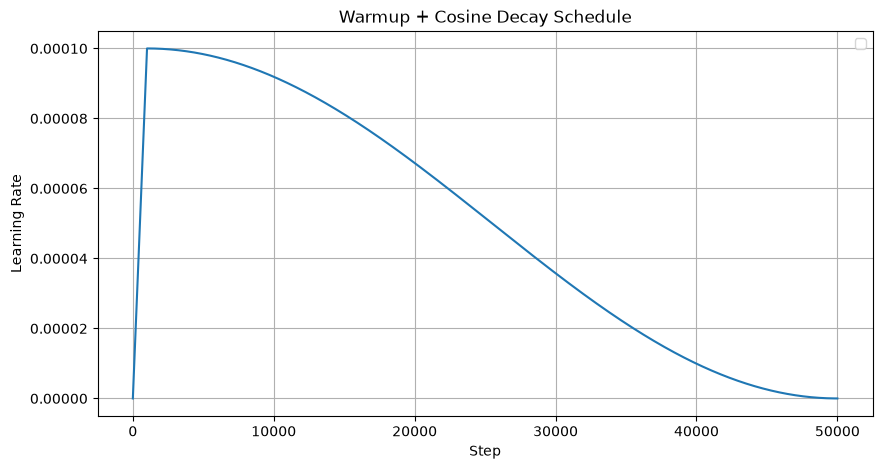

In [29]:
import math
import matplotlib.pyplot as plt

def get_lr_multiplier(current_step, warmup_steps=1000, total_steps=50000):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

# Paramètres
warmup_steps = 1000
total_steps = 50000
base_lr = 1e-4

# Calcul de la courbe
steps = list(range(0, total_steps))
multipliers = [get_lr_multiplier(s, warmup_steps, total_steps) for s in steps]
lrs = [base_lr * m for m in multipliers]

# Affichage
plt.figure(figsize=(10, 5))
plt.plot(steps, lrs)
#plt.axvline(x=warmup_steps, color='red', linestyle='--', label='Fin du warmup')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Warmup + Cosine Decay Schedule')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# tiny dataset test
import torch

vocab_size = 10
seq_len = 2

qst = torch.randint(1, vocab_size, (seq_len,))
answer = torch.sum(qst)
print(qst, answer)

tensor([7, 6]) tensor(13)
